# Safe Reinforcement Learning for Crypto Pair Trading

This notebook studies whether a shielded reinforcement learning execution policy can improve a dynamic cryptocurrency pair trading baseline. It uses real hourly Coinbase data, chronological evaluation, explicit trading costs, and deterministic risk limits.

The central finding is cautious. An unrestricted scaling policy fails badly. A permission gate reduces damage and drawdown, but the strategy remains unprofitable. This is a research result rather than a trading recommendation.

In [1]:
from pathlib import Path
import os, sys, subprocess

if 'google.colab' in sys.modules:
    if not Path('/content/safe-rl-crypto-pair-trading').exists():
        subprocess.run(['git', 'clone', 'https://github.com/am610/safe-rl-crypto-pair-trading.git'], check=True)
    os.chdir('/content/safe-rl-crypto-pair-trading')
elif Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-e', '.[rl]'], check=True)
print('Project root:', Path.cwd())

Project root: /Users/ayan/Programs/Quant/crypto_multi_pair_rl


## Research design

The experiment uses 2024 for training, 2025 for validation, and 2026 for exploratory evaluation. The word exploratory matters because the 2026 period was viewed during early policy diagnosis. Every strategy includes a one hour execution delay and ten basis points of turnover cost.

In [2]:
import json
import pandas as pd
from IPython.display import display, Image

products = ['BTC-USD', 'ETH-USD', 'SOL-USD', 'ADA-USD', 'DOGE-USD', 'LTC-USD']
summary = pd.DataFrame({
    'Period': ['Training', 'Validation', 'Exploratory evaluation'],
    'Dates': ['2024', '2025', '2026 through August 24'],
    'Purpose': ['Pair selection and policy fitting', 'Parameter and candidate selection', 'Locked comparison with disclosure'],
})
display(summary)

,Period,Dates,Purpose
0,Training,2024,Pair selection and policy fitting
1,Validation,2025,Parameter and candidate selection
2,Exploratory evaluation,2026 through August 24,Locked comparison with disclosure


## Real data and pair evolution

The pipeline downloads public hourly candles from Coinbase Exchange. Binance futures access is restricted in the development location, so this project does not make futures specific claims. The animation shows normalized BTC and DOGE prices, the fixed hedge spread z score, entry thresholds, and periods when the heuristic is active.

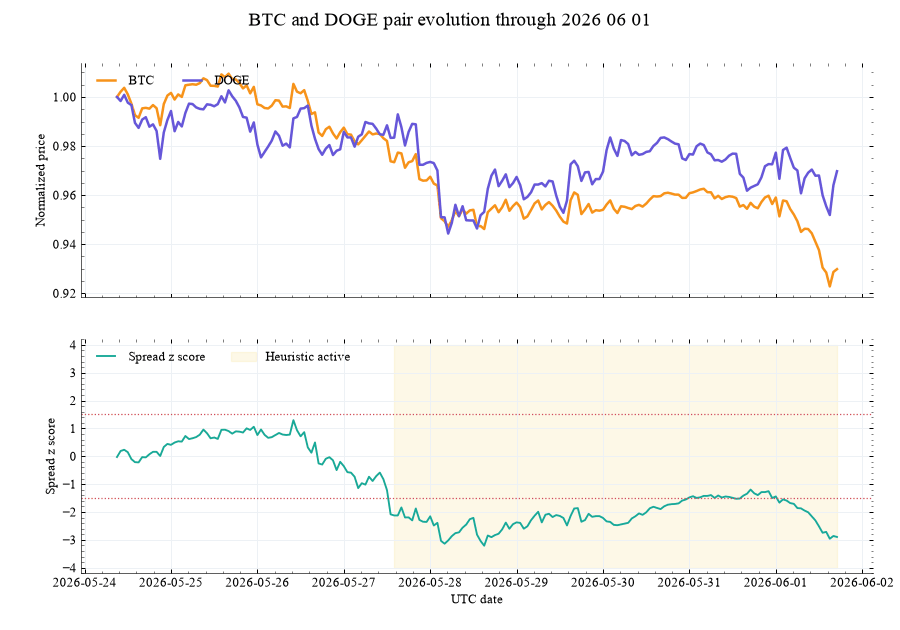

In [3]:
display(Image(filename='docs/assets/btc_doge_pair_evolution.gif'))

## Training only pair selection

The training screen selects BTC with DOGE, SOL with DOGE, and BTC with SOL. Hedge ratios and stationarity diagnostics are estimated without validation or evaluation observations.

In [4]:
heuristic = {
  "annual_return": -0.23571274543242984,
  "annual_volatility": 0.1329872837986693,
  "sharpe": -1.7724457459352096,
  "maximum_drawdown": 0.1796180016888167,
  "ending_wealth": 0.8544092098877786,
  "rows": 23175,
  "selected_pairs": [
    "BTC-USD with DOGE-USD",
    "SOL-USD with DOGE-USD",
    "BTC-USD with SOL-USD"
  ],
  "lookback": 336,
  "entry_z": 1.5,
  "exit_z": 0.5,
  "cost_bps": 10.0,
  "train_end": "2024-12-31T23:00:00+00:00",
  "validation_end": "2025-12-31T23:00:00+00:00"
}
pd.DataFrame({
    'Selected pair': heuristic['selected_pairs'],
    'Selection source': ['Training only'] * len(heuristic['selected_pairs'])
})

,Selected pair,Selection source
0,BTC-USD with DOGE-USD,Training only
1,SOL-USD with DOGE-USD,Training only
2,BTC-USD with SOL-USD,Training only


## Locked heuristic baseline

The deterministic baseline uses a 336 hour rolling window, a 1.5 standard deviation entry threshold, and a 0.5 standard deviation exit threshold. It fails on the exploratory evaluation period, which establishes a demanding but honest benchmark.

In [5]:
scaled = {
  "annual_return": -0.293213171657358,
  "annual_volatility": 0.06256210927776087,
  "sharpe": -4.686753292724855,
  "maximum_drawdown": 0.1823750531693239,
  "ending_wealth": 0.8270895309619242,
  "active_pair_hours": 4689,
  "activity_fraction": 0.8322683706070287,
  "shield_interventions": 716,
  "validation_sharpe": -1.4118460305251517,
  "validation_activity": 0.8356180031985379,
  "training_steps": 80000,
  "seed": 17,
  "activity_penalty_bps": 0.25,
  "candidate_count": 3,
  "evaluation_status": "exploratory because the 2026 period was viewed after the first policy"
}
gate = {
  "annual_return": -0.1348778058150544,
  "annual_volatility": 0.0795670869510589,
  "sharpe": -1.6951457063900894,
  "maximum_drawdown": 0.10885122256454338,
  "ending_wealth": 0.915043761522936,
  "seed": 41,
  "training_activity_penalty_bps": 2.0,
  "validation_sharpe": 0.7717138444841285,
  "validation_activity": 0.5391820881882567,
  "test_activity": 0.5908768193113241,
  "shield_interventions": 5,
  "evaluation_status": "exploratory because the 2026 period was previously viewed"
}

comparison = pd.DataFrame([
    {'Model': 'Locked heuristic', 'Sharpe': heuristic['sharpe'], 'Maximum drawdown': heuristic['maximum_drawdown'], 'Ending wealth': heuristic['ending_wealth']},
    {'Model': 'Scaled PPO', 'Sharpe': scaled['sharpe'], 'Maximum drawdown': scaled['maximum_drawdown'], 'Ending wealth': scaled['ending_wealth']},
    {'Model': 'Permission gate PPO', 'Sharpe': gate['sharpe'], 'Maximum drawdown': gate['maximum_drawdown'], 'Ending wealth': gate['ending_wealth']},
])
display(comparison.style.format({'Sharpe': '{:.2f}', 'Maximum drawdown': '{:.1%}', 'Ending wealth': '{:.2f}'}))

,Model,Sharpe,Maximum drawdown,Ending wealth
0,Locked heuristic,-1.77,18.0%,0.85
1,Scaled PPO,-4.69,18.2%,0.83
2,Permission gate PPO,-1.70,10.9%,0.92


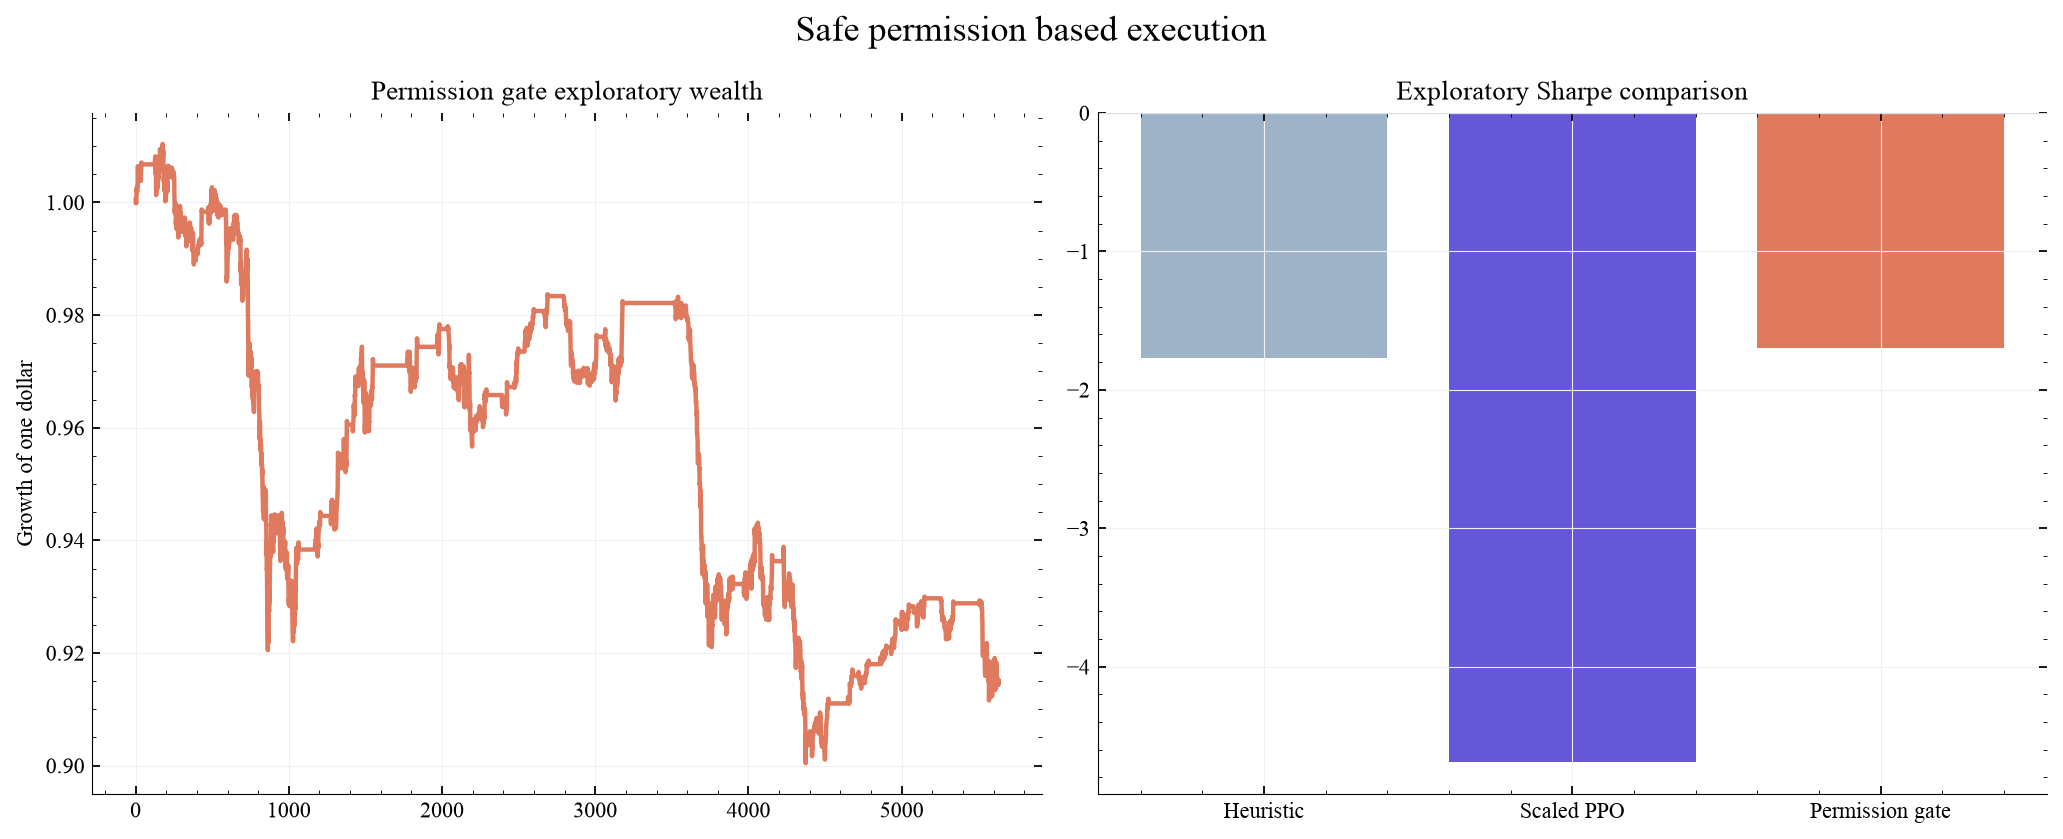

In [6]:
display(Image(filename='docs/assets/permission_gate.png'))

## What the reinforcement learning experiments show

The scaled PPO policy participates too often and performs far worse than the heuristic. The permission gate can only authorize or reject deterministic signals. It cannot choose direction, add leverage, or override the shield. This safer formulation improves drawdown and ending wealth, but it does not produce a profitable strategy.

The conclusion is therefore narrow and defensible: explicit abstention and deterministic shielding reduce damage in this experiment. They do not establish a durable cryptocurrency trading edge.

In [7]:
risk_controls = pd.DataFrame({
    'Control': ['Direction anchoring', 'Divergence shield', 'Concentration limit', 'Execution delay', 'Turnover cost'],
    'Implementation': ['Deterministic signal only', 'Forced flat beyond absolute z score 4', 'At most two active pairs', 'One hour', 'Ten basis points'],
})
display(risk_controls)

,Control,Implementation
0,Direction anchoring,Deterministic signal only
1,Divergence shield,Forced flat beyond absolute z score 4
2,Concentration limit,At most two active pairs
3,Execution delay,One hour
4,Turnover cost,Ten basis points


## Limitations and next evidence

1. Coinbase spot candles are not Binance futures observations.

2. The 2026 period is exploratory after early inspection.

3. Only three PPO candidates are compared in each controlled search.

4. Funding, order book impact, and exchange specific fill mechanics are not modeled.

5. Bootstrap uncertainty and cost sensitivity remain necessary before the research can be considered complete.